In [1]:
import warnings
warnings.filterwarnings('ignore')

In [376]:
import os
import gc
import itertools
import tqdm as notebook_tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import pyarrow.parquet as pq
import pickle

from tqdm.auto import tqdm

from sklearn.metrics import RocCurveDisplay, roc_curve, auc, classification_report, confusion_matrix
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier

from utils import reduce_mem_usage, plot_confusion_matrix, compute_weights

###  Обучение моделей на всех признаках

    Параметры модели взяты из предварительного анализа выполненно с помощью lightautoml (см. ноутбук Auto_ML.ipynb).
    Поскольку все данные тренеровочного датасета не помещаются в оперативную память, будет обучатся 3 модели (по числу row_groups в файле 'data_train_std.pq').
    
    Итоговое предсказание определяется одним из двух способ:
1. **Равные веса**: путем определения средней веротности.
2. **Пропорциональные веса**: путем суммирования произведения вероятностей на веса. Веса определяются как отношение записей в конкретной row_group к общему количеству записей в тренеровочном датасете.

In [123]:
PARAMS = {
    'objective': 'binary',
    'metric': 'auc',
    'feature_fraction': 0.8037724259507192, 
    'num_leaves': 56, 
    'bagging_fraction': 0.5325257964926398, 
    'min_sum_hessian_in_leaf': 6.245139574743075, 
    'reg_alpha': 4.905556676028774, 
    'reg_lambda': 0.18861495878553936,
    'num_threads': 2,
    'early_stopping_rounds': 500,
}

In [26]:
pf = pq.ParquetFile(r'../prep_data/data_train_std.pq')
for i in range(pf.num_row_groups):
    num_rows_in_rg = pf.metadata.row_group(i).num_rows
    print(f'Row group {i} содержит {num_rows_in_rg} строк')

Row group 0 содержит 1048576 строк
Row group 1 содержит 1048576 строк
Row group 2 содержит 302848 строк


In [8]:
models = {}

In [53]:
for row_group in range(pf.num_row_groups):
    print(f'Читаем row group: {row_group}')
    table = pf.read_row_group(row_group)
    batch = table.to_pandas()
    X = batch.drop(['id', 'flag'], axis=1)
    y = batch['flag']
    
    del batch
    gc.collect()

    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        shuffle=True,
        stratify=y
    )
    print(f'Размер X_train: {X_train.shape}, размер X_val: {X_val.shape}')
    print(f'Размер y_train: {y_train.shape}, размер y_val: {y_val.shape}')

    del X, y
    gc.collect()

    val_counts = 0.

    weights = compute_weights(y_train)
    
    train_data = lgb.Dataset(X_train, label=y_train, weight=weights)
    validation_data = train_data.create_valid(X_val, label=y_val)

    bst = lgb.train(PARAMS, train_data, num_boost_round=2000, valid_sets=[validation_data])

    key = 'lgb_model_' + str(row_group)
    file_name = key + '.pkl'

    with open(file_name, 'wb') as f:
        pickle.dump(bst, f)
    print(f'Модель сохранена в {file_name}')

    models[key] = bst

    del bst
    gc.collect()

Читаем row group: 0
Размер X_train: (838860, 386), размер X_val: (209716, 386)
Размер y_train: (838860,), размер y_val: (209716,)
Веса рассчитанные compute_weights: [ 0.51829216 14.16706073]
[LightGBM] [Info] Number of positive: 29606, number of negative: 809254
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.799673 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5227
[LightGBM] [Info] Number of data points in the train set: 838860, number of used features: 374
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 500 rounds
Early stopping, best iteration is:
[122]	valid_0's auc: 0.74829
Модель сохранена в lgb_model_0.pkl
Читаем row group: 1
Размер X_train: (838860, 386), размер X_val: (209716, 386)
Размер y_t

In [54]:
models

{'lgb_model_0': <lightgbm.basic.Booster at 0x74b8f43b7550>,
 'lgb_model_1': <lightgbm.basic.Booster at 0x74b8cc35bd30>,
 'lgb_model_2': <lightgbm.basic.Booster at 0x74b8cc35bdc0>}

In [25]:
tf = pq.ParquetFile(r'../prep_data/data_test_std.pq')
table = tf.read_row_group(0)
X_test = table.to_pandas()
y_test = X_test['flag']
X_test = X_test.drop(['id', 'flag'], axis=1)
X_test.shape, y_test.shape

((600000, 386), (600000,))

In [56]:
y_pred_proba = {}

In [57]:
for model in models.keys():
    y_pred = models[model].predict(X_test)
    y_pred_proba[model] = y_pred

In [58]:
y_pred_proba

{'lgb_model_0': array([0.73347303, 0.42604193, 0.65126435, ..., 0.35357639, 0.29771287,
        0.29251112]),
 'lgb_model_1': array([0.73034265, 0.3608073 , 0.59554773, ..., 0.35619793, 0.17480259,
        0.2296672 ]),
 'lgb_model_2': array([0.70833965, 0.55511165, 0.39699997, ..., 0.21569629, 0.39314304,
        0.27918995])}

In [59]:
df_preds = pd.DataFrame(y_pred_proba)

In [60]:
df_preds.head()

,lgb_model_0,lgb_model_1,lgb_model_2
0,0.733473,0.730343,0.708340
1,0.426042,0.360807,0.555112
2,0.651264,0.595548,0.397000
3,0.457765,0.503532,0.521042
4,0.566329,0.512148,0.631447


In [30]:
model_weights = []

In [31]:
for i in range(pf.num_row_groups):
    model_weights.append(pf.metadata.row_group(i).num_rows / pf.metadata.num_rows)
model_weights  

[0.43690666666666667, 0.43690666666666667, 0.12618666666666667]

In [41]:
df_preds['mid'] = (df_preds['lgb_model_0'] + df_preds['lgb_model_1'] + df_preds['lgb_model_2']) / 3

In [42]:
df_preds['weights'] = df_preds['lgb_model_0'] * model_weights[0] + df_preds['lgb_model_1'] * model_weights[1] + df_preds['lgb_model_2'] * model_weights[2]

In [43]:
df_preds['mid_binary_50'] = (df_preds['mid'] > 0.5).astype(int)
df_preds['weights_binary'] = (df_preds['weights'] > 0.5).astype(int)

In [47]:
df_preds['true'] = y_test
df_preds.head()

,lgb_model_0,lgb_model_1,lgb_model_2,mid,mid_binary_50,weights,weights_binary,true
0,0.733473,0.730343,0.708340,0.724052,1,0.728934,1,0
1,0.426042,0.360807,0.555112,0.447320,0,0.413827,0,0
2,0.651264,0.595548,0.397000,0.547937,1,0.594837,1,0
3,0.457765,0.503532,0.521042,0.494113,0,0.485745,0,0
4,0.566329,0.512148,0.631447,0.569974,1,0.550874,1,0


In [48]:
df_preds[df_preds['mid_binary_50'] != df_preds['weights_binary']]

,lgb_model_0,lgb_model_1,lgb_model_2,mid,mid_binary_50,weights,weights_binary,true
31,0.572205,0.525345,0.349329,0.482293,0,0.523607,1,0
46,0.481206,0.558413,0.454277,0.497966,0,0.511540,1,0
96,0.485959,0.589316,0.404077,0.493117,0,0.520784,1,0
113,0.475037,0.561121,0.420393,0.485517,0,0.505752,1,0
135,0.471604,0.478601,0.566233,0.505479,1,0.486602,0,0
...,...,...,...,...,...,...,...,...
599761,0.508404,0.459674,0.540174,0.502750,1,0.491122,0,0
599810,0.624039,0.520861,0.217114,0.454005,0,0.527611,1,0
599814,0.644428,0.441306,0.365973,0.483903,0,0.520546,1,0
599898,0.607126,0.432851,0.457700,0.499226,0,0.512129,1,0


In [49]:
df_preds.to_csv('lgb_preds.csv')

In [50]:
print(classification_report(df_preds['true'], df_preds['mid_binary_50']))

              precision    recall  f1-score   support

           0       0.98      0.62      0.76    578712
           1       0.06      0.69      0.12     21288

    accuracy                           0.62    600000
   macro avg       0.52      0.66      0.44    600000
weighted avg       0.95      0.62      0.74    600000



In [51]:
print(classification_report(df_preds['true'], df_preds['weights_binary']))

              precision    recall  f1-score   support

           0       0.98      0.61      0.75    578712
           1       0.06      0.71      0.11     21288

    accuracy                           0.61    600000
   macro avg       0.52      0.66      0.43    600000
weighted avg       0.95      0.61      0.73    600000



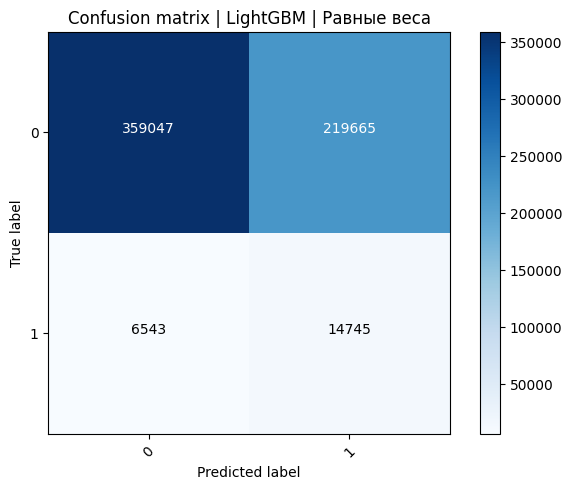

In [55]:
plot_confusion_matrix(confusion_matrix(df_preds['true'], df_preds['mid_binary_50']), classes=['0','1'],
                      title='Confusion matrix | LightGBM | Равные веса')
plt.savefig('pictures/LightGBM_model_mid.png', bbox_inches='tight')

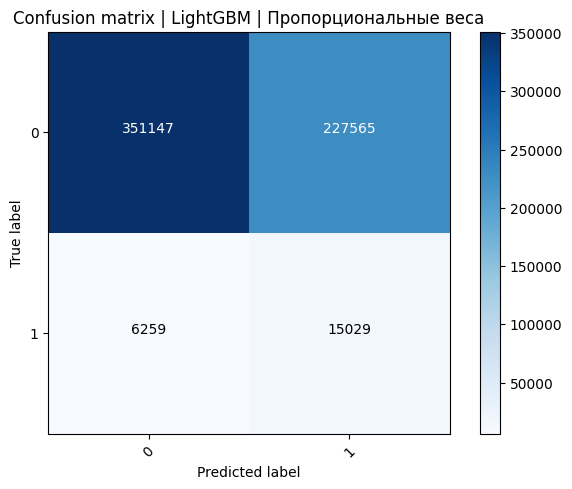

In [56]:
plot_confusion_matrix(confusion_matrix(df_preds['true'], df_preds['weights_binary']), classes=['0','1'],
                      title='Confusion matrix | LightGBM | Пропорциональные веса')
plt.savefig('pictures/LightGBM_model_weights.png', bbox_inches='tight')

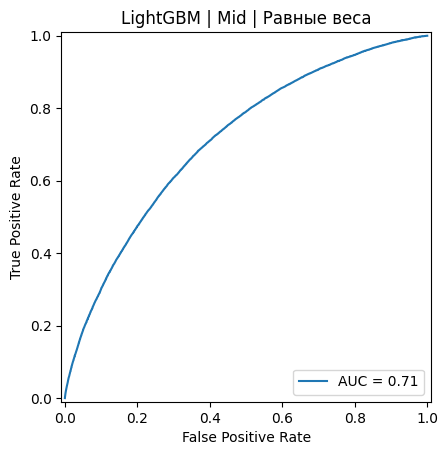

In [57]:
 # Посчитаем значение метрики AUC и построим ROC кривую
fpr, tpr, _ = roc_curve(df_preds['true'], df_preds['mid'])
roc_auc = auc(fpr, tpr)

RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()
plt.title('LightGBM | Mid | Равные веса')
plt.savefig('pictures/LightGBM_model_roc_mid.png', bbox_inches='tight');

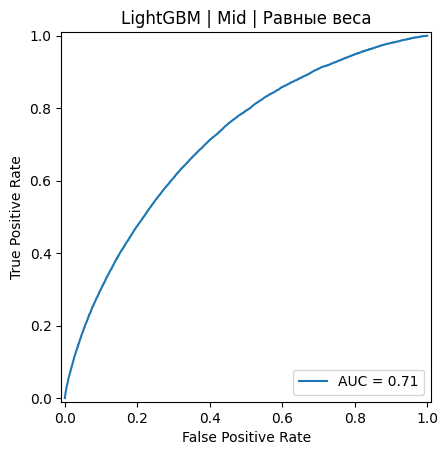

In [58]:
fpr, tpr, _ = roc_curve(df_preds['true'], df_preds['weights'])
roc_auc = auc(fpr, tpr)

RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()
plt.title('LightGBM | Mid | Равные веса')
plt.savefig('pictures/LightGBM_model_roc_weights.png', bbox_inches='tight')

Модель с пропорциональнми весами показывает, чуть лучшее качество, но AUC не достаточен.

### Отбор признаков и обучение моделей на них

    Для улучшения качества модели попробую провести отбор признаков для обучения по критерию .feature_importance обученных на предыдущем шаге моделей. Важность определяется аналогично двумя методами: равные веса и пропорциональные веса.

In [74]:
feat_dict = {}

In [79]:
for model in models.keys():
    feat_dict[model] = models[model].feature_importance(importance_type='gain')
    feature_names = models[model].feature_name() 

In [80]:
df_feat = pd.DataFrame(feat_dict, index=feature_names)

In [82]:
df_feat['mid'] = (df_feat['lgb_model_0'] + df_feat['lgb_model_1'] + df_feat['lgb_model_2']) / 3
df_feat['weights'] = df_feat['lgb_model_0'] * model_weights[0] + df_feat['lgb_model_1'] * model_weights[1] + df_feat['lgb_model_2'] * model_weights[2]

In [83]:
df_feat.head()

,lgb_model_0,lgb_model_1,lgb_model_2,mid,weights
pre_pterm_14_std,2070.090504,3316.452679,1171.329807,2185.957663,2501.222831
pre_pterm_15_std,2130.050102,1657.956570,723.235100,1503.747257,1746.267995
pre_pterm_16_std,1089.897301,1736.763695,255.347900,1027.336299,1267.208534
pre_pterm_17_std,1209.127113,2129.278698,700.131203,1346.179005,1546.918978
pre_fterm_1_std,1148.577499,1635.959616,558.903904,1114.480340,1287.109050


In [113]:
df_sorted_mid = df_feat.sort_values(by='mid', ascending=False)
top_50_mid = df_sorted_mid.index[:50]

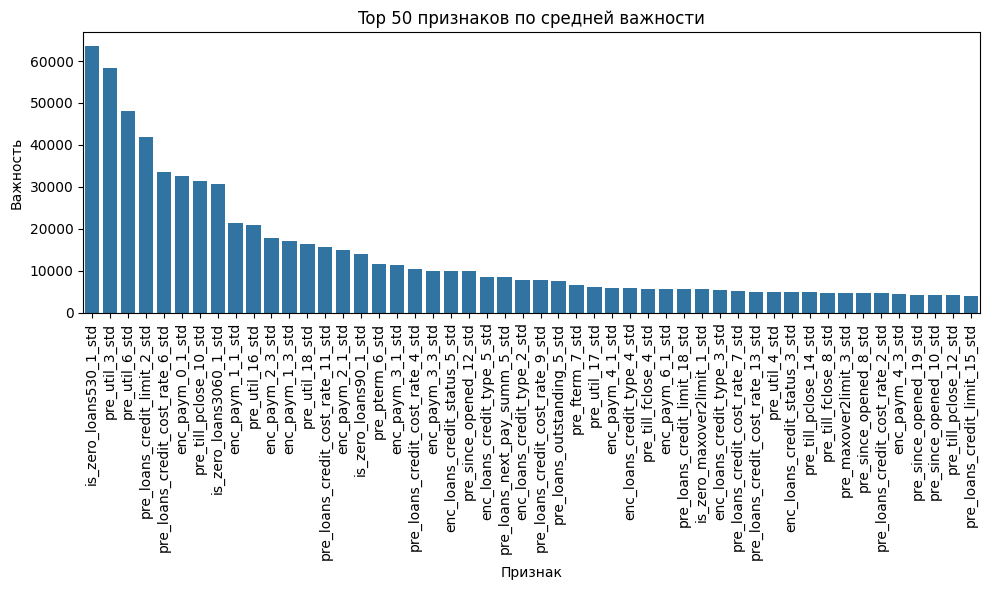

In [114]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_sorted_mid.head(50), x=top_50_mid, y='mid')
plt.title('Top 50 признаков по средней важности')
plt.xlabel('Признак')
plt.xticks(rotation=90)
plt.ylabel('Важность')
plt.tight_layout()
plt.show()

In [115]:
df_sorted_weights = df_feat.sort_values(by='weights', ascending=False)
top_50_wts = df_sorted_weights.index[:50]

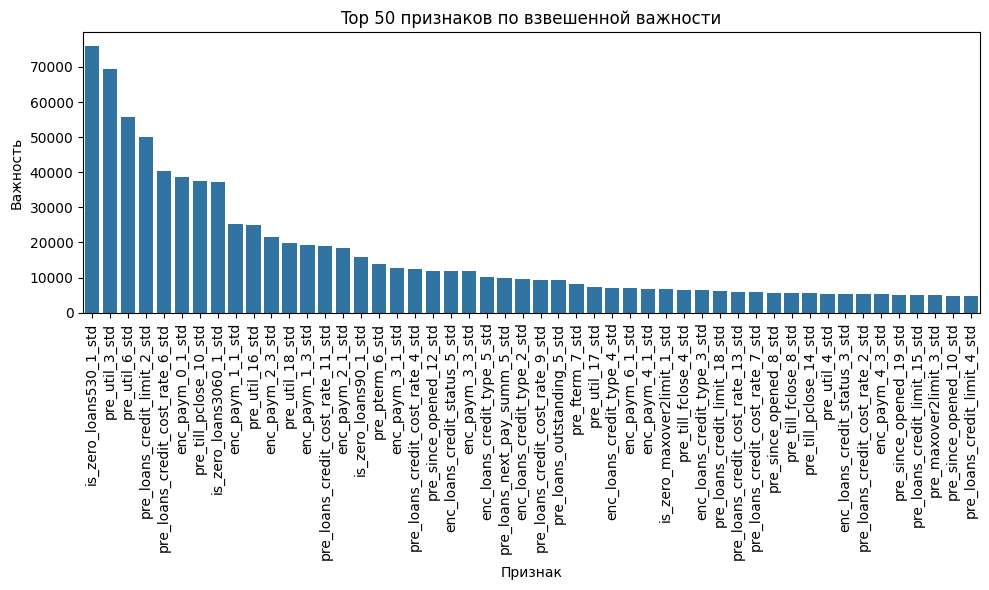

In [116]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_sorted_weights.head(50), x=top_50_wts, y='weights')
plt.title('Top 50 признаков по взвешенной важности')
plt.xlabel('Признак')
plt.xticks(rotation=90)
plt.ylabel('Важность')
plt.tight_layout()
plt.show()

Отличия в важности имеются, но не значительны (первое отличие появляется на 12 индексе). Основной вклад вносят следующие 10 признаков:
1. 'is_zero_loans530_1_std' - флаг, нет просрочек от 5 до 30 дней;
2. 'pre_util_3_std' - отношение оставшейся невыплаченной суммы кредита к кредитному лимиту (бинаризованное значение 3)
3. 'pre_util_6_std' - отношение оставшейся невыплаченной суммы кредита к кредитному лимиту (бинаризованное значение 6)
4. 'pre_loans_credit_limit_2_std' - кридитный лимит (бинаризованное значение 2)
5. 'pre_loans_credit_cost_rate_6_std' - полная стоимость кредита (бинаризованное значение 6)
6. 'enc_paym_0_1_std' - статус ежемесячного платежа за последний месяц (закодированное значение 1),
7. 'pre_till_pclose_10_std' - плановое количиство дней с даты сбора данных до даты закрытия (бинаризованное значение 10),
8. 'is_zero_loans3060_1_std' - флаг, нет просрочек от 30 до 60 дней;
9. 'enc_paym_1_1_std' статус ежемесячного платежа за последние два месяца (закодированное значение 1),
10. 'pre_util_16_std' - отношение оставшейся невыплаченной суммы кредита к кредитному лимиту (бинаризованное значение 16)


#### Обучение моделей на разном количестве признаков, отсортировванных по важности. Усреднение моделей равными весами.

In [352]:
top_mid = df_sorted_mid.index[:130]

In [353]:
models_top_mid = {}

In [354]:
tf = pq.ParquetFile('data_test_std.pq')
table = tf.read_row_group(0)
X_test = table.to_pandas()
y_test = X_test['flag']
X_test = X_test[top_mid]
X_test.shape, y_test.shape

((600000, 130), (600000,))

In [355]:
for row_group in range(pf.num_row_groups):
    print(f'Читаем row group: {row_group}')
    table = pf.read_row_group(row_group)
    batch = table.to_pandas()
    X = batch[top_mid]
    y = batch['flag']
    
    del batch
    gc.collect()

    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        shuffle=True,
        stratify=y
    )
    print(f'Размер X_train: {X_train.shape}, размер X_val: {X_val.shape}')
    print(f'Размер y_train: {y_train.shape}, размер y_val: {y_val.shape}')

    del X, y
    gc.collect()

    val_counts = 0.

    weights = compute_weights(y_train)
    
    train_data = lgb.Dataset(X_train, label=y_train, weight=weights)
    validation_data = train_data.create_valid(X_val, label=y_val)

    bst = lgb.train(PARAMS, train_data, num_boost_round=2000, valid_sets=[validation_data])

    key = 'lgb_model_' + str(row_group)

    models_top_mid[key] = bst

    del bst
    gc.collect()

Читаем row group: 0
Размер X_train: (838860, 130), размер X_val: (209716, 130)
Размер y_train: (838860,), размер y_val: (209716,)
Веса рассчитанные compute_weights: [ 0.51829216 14.16706073]
[LightGBM] [Info] Number of positive: 29606, number of negative: 809254
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.300876 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2813
[LightGBM] [Info] Number of data points in the train set: 838860, number of used features: 130
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 500 rounds
Early stopping, best iteration is:
[90]	valid_0's auc: 0.746257
Читаем row group: 1
Размер X_train: (838860, 130), размер X_val: (209716, 130)
Размер y_train: (838860,), размер y_val: (209

In [356]:
y_proba_mid = {}
for model in models_top_mid.keys():
    y_pred = models_top_mid[model].predict(X_test)
    y_proba_mid[model] = y_pred

In [357]:
df_preds_mid = pd.DataFrame(y_proba_mid)
df_preds_mid.head()

,lgb_model_0,lgb_model_1,lgb_model_2
0,0.752866,0.781231,0.745139
1,0.286679,0.173573,0.321140
2,0.538130,0.433840,0.410527
3,0.444565,0.407246,0.471697
4,0.457492,0.451306,0.597282


In [358]:
df_preds_mid['mid'] = (df_preds_mid['lgb_model_0'] + df_preds_mid['lgb_model_1'] + df_preds_mid['lgb_model_2']) / 3

In [359]:
df_preds_mid['mid_binary'] = (df_preds_mid['mid'] > 0.5).astype(int)

In [360]:
df_preds_mid['true'] = y_test

In [361]:
df_preds_mid.head()

,lgb_model_0,lgb_model_1,lgb_model_2,mid,mid_binary,true
0,0.752866,0.781231,0.745139,0.759746,1,0
1,0.286679,0.173573,0.321140,0.260464,0,0
2,0.538130,0.433840,0.410527,0.460832,0,0
3,0.444565,0.407246,0.471697,0.441169,0,0
4,0.457492,0.451306,0.597282,0.502027,1,0


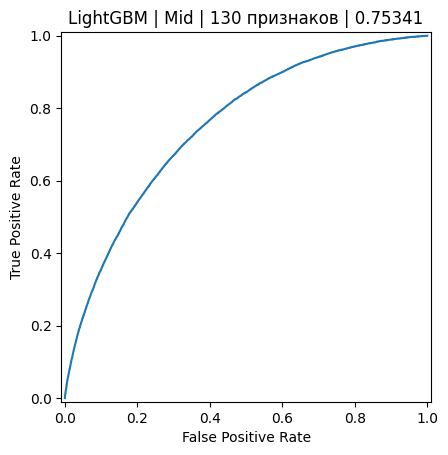

In [374]:
 # Посчитаем значение метрики AUC и построим ROC кривую
fpr, tpr, _ = roc_curve(df_preds_mid['true'], df_preds_mid['mid'])
roc_auc_mid = auc(fpr, tpr)

RocCurveDisplay(fpr=fpr, tpr=tpr).plot()
plt.title(f'LightGBM | Mid | 130 признаков | {roc_auc_mid:.5f}')
plt.savefig('pictures/LightGBM_model_roc_top_mid.png', bbox_inches='tight');

Существенное увеличение AUC = 0.75341 удалось добится на первых 130 признаках.

#### Обучение моделей на разном количестве признаков, отсортировванных по важности. Усреднение моделей равными весами.

In [363]:
top_wts = df_sorted_weights.index[:130]

In [364]:
models_top_wts = {}

In [365]:
tf = pq.ParquetFile('data_test_std.pq')
table = tf.read_row_group(0)
X_test = table.to_pandas()
y_test = X_test['flag']
X_test = X_test[top_wts]
X_test.shape, y_test.shape

((600000, 130), (600000,))

In [366]:
for row_group in range(pf.num_row_groups):
    print(f'Читаем row group: {row_group}')
    table = pf.read_row_group(row_group)
    batch = table.to_pandas()
    X = batch[top_wts]
    y = batch['flag']
    
    del batch
    gc.collect()

    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        shuffle=True,
        stratify=y
    )
    print(f'Размер X_train: {X_train.shape}, размер X_val: {X_val.shape}')
    print(f'Размер y_train: {y_train.shape}, размер y_val: {y_val.shape}')

    del X, y
    gc.collect()

    val_counts = 0.

    weights = compute_weights(y_train)
    
    train_data = lgb.Dataset(X_train, label=y_train, weight=weights)
    validation_data = train_data.create_valid(X_val, label=y_val)

    bst = lgb.train(PARAMS, train_data, num_boost_round=2000, valid_sets=[validation_data])

    key = 'lgb_model_' + str(row_group)

    models_top_wts[key] = bst

    del bst
    gc.collect()

Читаем row group: 0
Размер X_train: (838860, 130), размер X_val: (209716, 130)
Размер y_train: (838860,), размер y_val: (209716,)
Веса рассчитанные compute_weights: [ 0.51829216 14.16706073]
[LightGBM] [Info] Number of positive: 29606, number of negative: 809254
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.294834 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2819
[LightGBM] [Info] Number of data points in the train set: 838860, number of used features: 130
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 500 rounds
Early stopping, best iteration is:
[122]	valid_0's auc: 0.746117
Читаем row group: 1
Размер X_train: (838860, 130), размер X_val: (209716, 130)
Размер y_train: (838860,), размер y_val: (20

In [367]:
y_proba_wts = {}
for model in models_top_wts.keys():
    y_pred = models_top_wts[model].predict(X_test)
    y_proba_wts[model] = y_pred

In [368]:
df_preds_wts = pd.DataFrame(y_proba_wts)
df_preds_wts.head()

,lgb_model_0,lgb_model_1,lgb_model_2
0,0.769163,0.761798,0.726117
1,0.240446,0.192375,0.310480
2,0.422095,0.419465,0.499163
3,0.442701,0.413297,0.490355
4,0.453787,0.462074,0.417647


In [369]:
df_preds_wts['weights'] = df_preds_wts['lgb_model_0'] * model_weights[0] + df_preds_wts['lgb_model_1'] * model_weights[1] + df_preds_wts['lgb_model_2'] * model_weights[2]

In [370]:
df_preds_wts['wts_binary'] = (df_preds_wts['weights'] > 0.5).astype(int)

In [371]:
df_preds_wts['true'] = y_test

In [372]:
df_preds_wts.head()

,lgb_model_0,lgb_model_1,lgb_model_2,weights,wts_binary,true
0,0.769163,0.761798,0.726117,0.760513,1,0
1,0.240446,0.192375,0.310480,0.228281,0,0
2,0.422095,0.419465,0.499163,0.430671,0,0
3,0.442701,0.413297,0.490355,0.435868,0,0
4,0.453787,0.462074,0.417647,0.452848,0,0


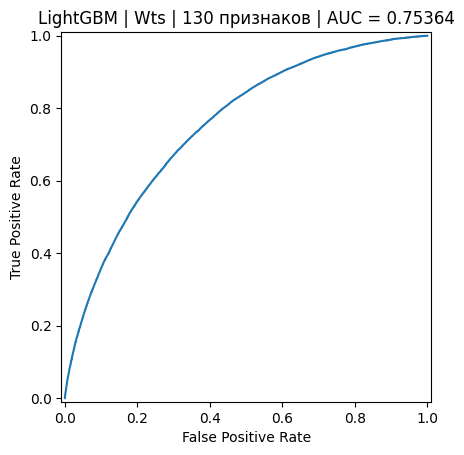

In [375]:
 # Посчитаем значение метрики AUC и построим ROC кривую
fpr, tpr, _ = roc_curve(df_preds_wts['true'], df_preds_wts['weights'])
roc_auc_wts = auc(fpr, tpr)

RocCurveDisplay(fpr=fpr, tpr=tpr).plot()
plt.title(f'LightGBM | Wts | 130 признаков | AUC = {roc_auc_wts:.5f}')
plt.savefig('pictures/LightGBM_model_roc_top_wts.png', bbox_inches='tight');

Пропорциональное усреднение позволило несколько увелить AUC с 0.75341 до 0.75364. Максимум также на первых 130 признаках.

#### Сохранение ансамбевой модели, полученной на обучении по 130 наиболее важным признакам с пропорциональным усреднением.

In [378]:
estimators = [
    ('lgb_model_0', models_top_wts['lgb_model_0']),
    ('lgb_model_1', models_top_wts['lgb_model_1']),
    ('lgb_model_2', models_top_wts['lgb_model_2'])
]

In [380]:
voting_clf = VotingClassifier(
    estimators=estimators,
    voting='soft',
    weights=model_weights
)

In [381]:
with open('lgd_voting_ensemble.pkl', 'wb') as f:
    pickle.dump(voting_clf, f)